In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score
import joblib
import time
import warnings
warnings.filterwarnings('ignore')

print("Loading data...")
start = time.time()
X_train = pd.read_csv('../data/X_train_scaled.csv')
X_test = pd.read_csv('../data/X_test_scaled.csv')
y_train = pd.read_csv('../data/y_train.csv')['target']
y_test = pd.read_csv('../data/y_test.csv')['target']
print(f"Loaded in {time.time()-start:.0f}s")

target_encoder = joblib.load('../models/target_encoder.joblib')
class_names = target_encoder.classes_

print(f"\nTrain: {X_train.shape[0]:,} samples, {X_train.shape[1]} features")
print(f"Test:  {X_test.shape[0]:,} samples")
print(f"Classes: {list(class_names)}")

Loading data...
Loaded in 58s

Train: 2,016,638 samples, 78 features
Test:  504,160 samples
Classes: [np.str_('Benign'), np.str_('Botnet'), np.str_('Brute Force'), np.str_('DoS/DDoS'), np.str_('Infiltration'), np.str_('Reconnaissance'), np.str_('Web Attack')]


In [2]:
# BASELINE Random Forest
print("Training baseline Random Forest...")
start_time = time.time()

baseline_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

baseline_rf.fit(X_train, y_train)
train_time = time.time() - start_time
print(f"Training complete in {train_time:.1f} seconds")

Training baseline Random Forest...
Training complete in 96.8 seconds


In [3]:
# Evaluate baseline
y_train_pred = baseline_rf.predict(X_train)
y_test_pred = baseline_rf.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Training accuracy: {train_acc*100:.2f}%")
print(f"Test accuracy:     {test_acc*100:.2f}%")
print(f"Gap: {(train_acc - test_acc)*100:.2f}%")

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT — BASELINE (TEST SET)")
print("=" * 60)
print(classification_report(y_test, y_test_pred, target_names=class_names))

Training accuracy: 99.95%
Test accuracy:     99.89%
Gap: 0.05%

CLASSIFICATION REPORT — BASELINE (TEST SET)
                precision    recall  f1-score   support

        Benign       1.00      1.00      1.00    419012
        Botnet       0.90      0.74      0.81       389
   Brute Force       1.00      1.00      1.00      1830
      DoS/DDoS       1.00      1.00      1.00     64354
  Infiltration       1.00      0.43      0.60         7
Reconnaissance       0.99      1.00      0.99     18139
    Web Attack       0.99      0.97      0.98       429

      accuracy                           1.00    504160
     macro avg       0.98      0.88      0.91    504160
  weighted avg       1.00      1.00      1.00    504160



Top 20 Most Important Features:

  Avg Bwd Segment Size                0.0809
  Packet Length Std                   0.0703
  Packet Length Variance              0.0687
  Max Packet Length                   0.0586
  Bwd Packet Length Max               0.0537
  Bwd Packet Length Std               0.0517
  Average Packet Size                 0.0410
  Bwd Packet Length Mean              0.0331
  Total Length of Bwd Packets         0.0324
  Packet Length Mean                  0.0306
  Subflow Fwd Packets                 0.0266
  Subflow Bwd Bytes                   0.0241
  Total Fwd Packets                   0.0227
  Total Length of Fwd Packets         0.0214
  Subflow Fwd Bytes                   0.0203
  Destination Port                    0.0202
  PSH Flag Count                      0.0186
  Fwd Header Length                   0.0183
  Fwd IAT Std                         0.0168
  Fwd Header Length.1                 0.0157


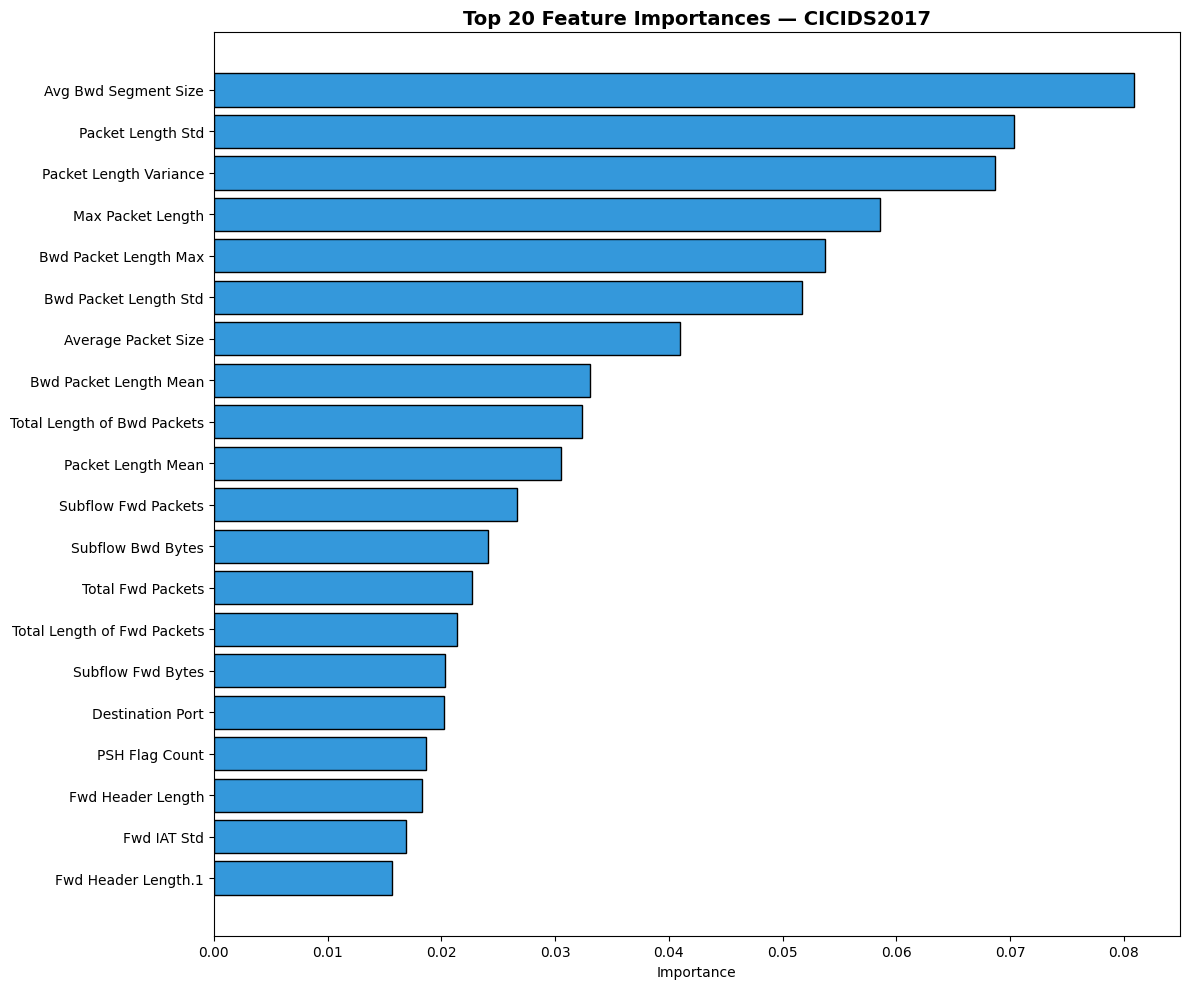

In [4]:
# FEATURE IMPORTANCE — what is the model using to detect attacks?
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': baseline_rf.feature_importances_
}).sort_values('importance', ascending=False)

# Top 20
print("Top 20 Most Important Features:\n")
for _, row in feature_importance.head(20).iterrows():
    print(f"  {row['feature']:35s} {row['importance']:.4f}")

# Visualize
fig, ax = plt.subplots(figsize=(12, 10))
top_20 = feature_importance.head(20)
ax.barh(range(len(top_20)), top_20['importance'], color='#3498db', edgecolor='black')
ax.set_yticks(range(len(top_20)))
ax.set_yticklabels(top_20['feature'])
ax.invert_yaxis()
ax.set_title('Top 20 Feature Importances — CICIDS2017', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

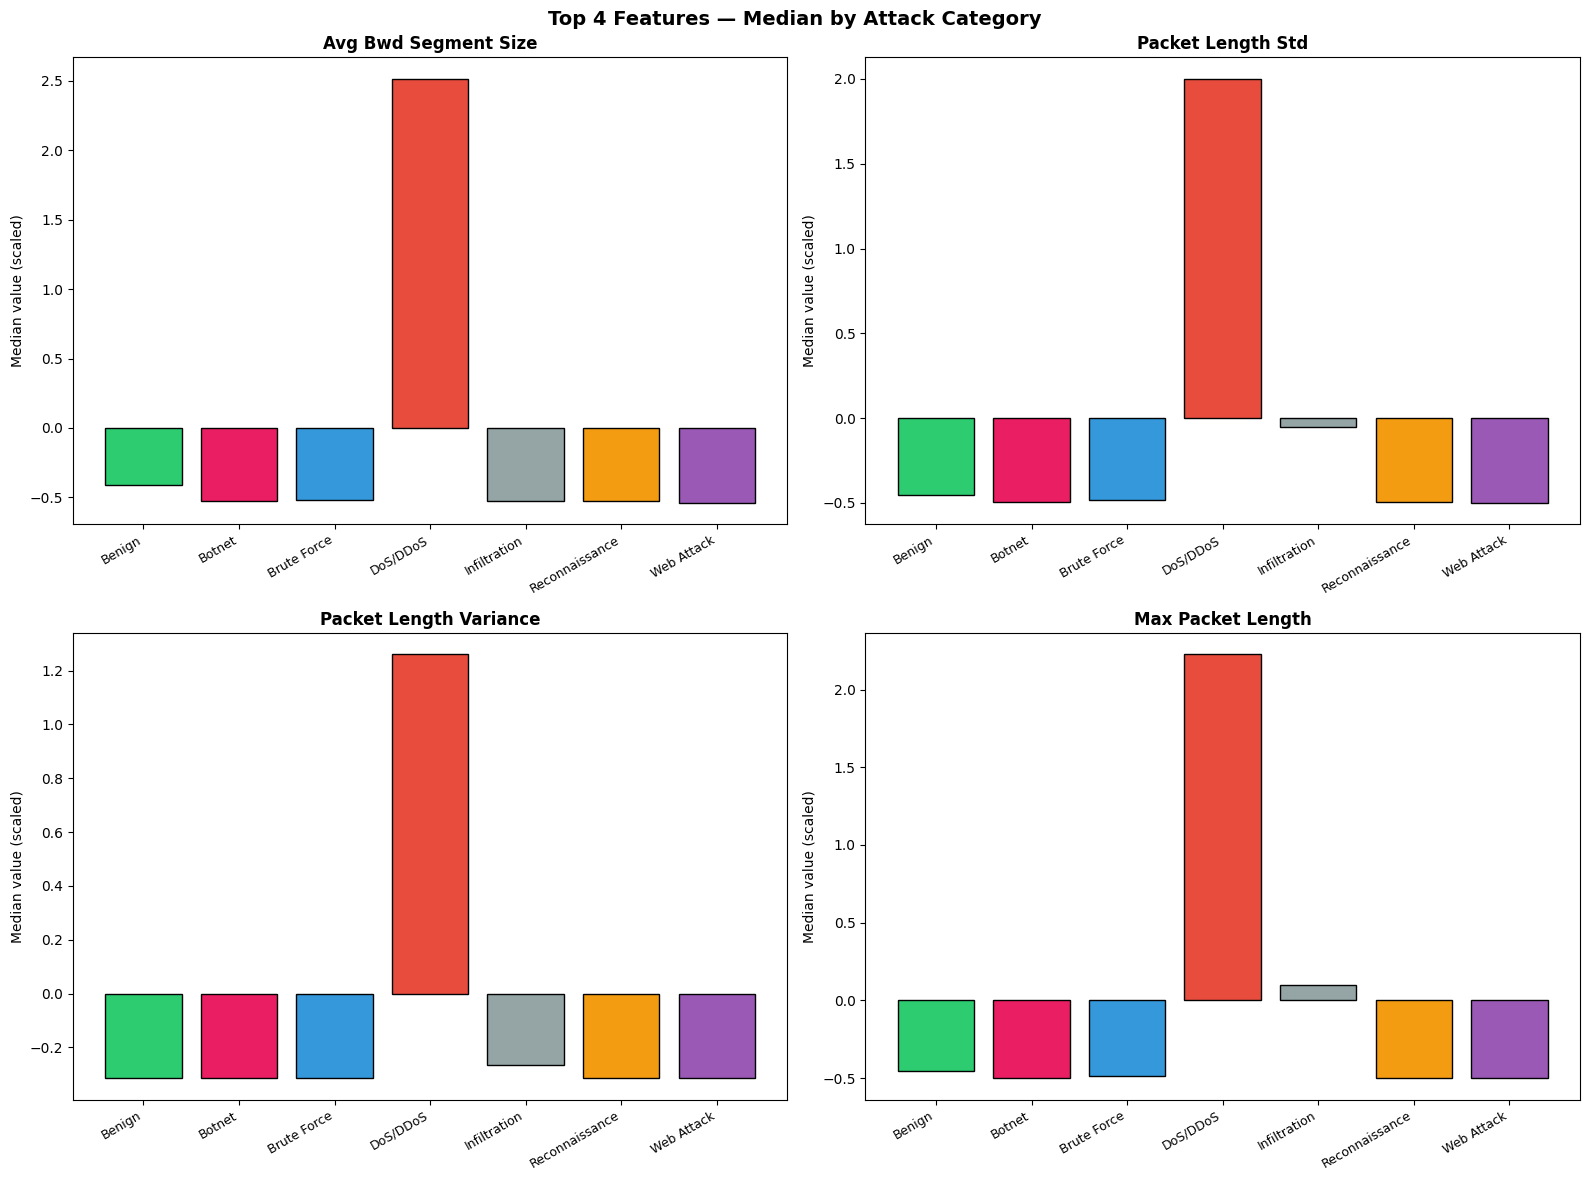

In [5]:
# Feature distributions for key attacks vs benign
# Pick the top 4 most important features and see how they differ

top_4 = feature_importance.head(4)['feature'].tolist()

# We need the unscaled data for interpretable plots, so let's load the raw
# Actually let's use the scaled data — patterns are the same

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Reload raw labels for plotting
target_map = dict(zip(range(len(class_names)), class_names))
plot_labels = pd.Series(y_test).map(target_map)

for idx, (ax, feat) in enumerate(zip(axes.flatten(), top_4)):
    data_by_class = {}
    for cls in class_names:
        mask = plot_labels == cls
        vals = X_test[feat][mask.values]
        data_by_class[cls] = vals.median()

    classes = list(data_by_class.keys())
    medians = list(data_by_class.values())
    colors = ['#2ecc71', '#e91e63', '#3498db', '#e74c3c', '#95a5a6', '#f39c12', '#9b59b6']

    ax.bar(classes, medians, color=colors, edgecolor='black')
    ax.set_title(f'{feat}', fontsize=12, fontweight='bold')
    ax.set_xticklabels(classes, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('Median value (scaled)')

plt.suptitle('Top 4 Features — Median by Attack Category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
# Save model and feature importance
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': baseline_rf.feature_importances_
}).sort_values('importance', ascending=False)

joblib.dump(baseline_rf, '../models/random_forest.joblib')
feature_importance.to_csv('../data/feature_importance.csv', index=False)

print("Saved:")
print("  models/random_forest.joblib")
print("  data/feature_importance.csv")
print("\nPhase 3 complete!")

Saved:
  models/random_forest.joblib
  data/feature_importance.csv

Phase 3 complete!
